In [34]:
import sys
import os 
import pandas as pd
#concectamos con la carpeta src
sys.path.append(os.path.abspath('../src'))
from data_processing import load_and_process_all

#ejecuta todo el flujo de una vez
df_completo = load_and_process_all(r'C:\Users\joseb\Desktop\proyecto _cm_ml\data\raw_data')

#verificar resultados
print(df_completo.groupby('Archivo_Origen')['Total'].sum()) #ver ventas por familias
df_completo.head()

📂 Procesando 2 archivos...
   Processing: productos_clientes_MC_raw.csv...
   Processing: productos_clientes_SI_raw.csv...
✅ ¡ÉXITO! 71780 filas limpias.
Archivo_Origen
productos_clientes_MC_raw.csv    3244308.50
productos_clientes_SI_raw.csv     743776.98
Name: Total, dtype: float64


,Fecha,Cliente,Segmento,Grupo,Producto,Cantidad,Total,Archivo_Origen,Año,Mes
0,2022-04-08,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,156,12110.0,1.0,productos_clientes_MC_raw.csv,2022,4
1,2022-05-11,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,156,12110.0,1.0,productos_clientes_MC_raw.csv,2022,5
2,2022-07-07,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,156,12110.0,1.0,productos_clientes_MC_raw.csv,2022,7
3,2022-09-17,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,1775,19580.0,1.0,productos_clientes_MC_raw.csv,2022,9
4,2023-10-27,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,1775,21570.0,1.0,productos_clientes_MC_raw.csv,2023,10


In [35]:
# Paso 1: preparacion de series temporales 
#-------------------------------------------------------------------------------------
print("Transformando datos a series Temporales")

# A) Extraer ID numerico del producto (Ej: '5939 CALKOR' --> '5939')
# Si no tiene numero, se queda con el nombre original.
df_completo['ID_Producto'] = df_completo['Producto'].astype(str).str.extract(r'^(\d+)')[0]
df_completo['ID_Producto'] = df_completo['ID_Producto'].fillna(df_completo['Producto'])

# B) Agrupar por Mes y Producto
# Queremos: que producto? cuando? cuanto?
df_ts = df_completo.groupby(['ID_Producto', 'Producto', 'Año', 'Mes'])['Cantidad'].sum().reset_index()

# Crear  columna fecha real ( dia 1 de cada mes) para facilitar el orden
df_ts['Fecha_Mensual'] = pd.to_datetime(df_ts['Año'].astype(str) + '-' + df_ts['Mes'].astype(str) + '-01')

print(f"Filas originales: {len(df_completo)}")
print(f'Filas agrupadas por mes: {len(df_ts)}')
df_ts

Transformando datos a series Temporales
Filas originales: 71780
Filas agrupadas por mes: 19196


,ID_Producto,Producto,Año,Mes,Cantidad,Fecha_Mensual
0,100,100,2022,6,176000.0,2022-06-01
1,100,100,2022,7,176000.0,2022-07-01
2,100,100,2022,9,176000.0,2022-09-01
3,100,100,2022,11,533500.0,2022-11-01
4,100,100,2023,2,416000.0,2023-02-01
...,...,...,...,...,...,...
19191,998,998,2023,11,115500.0,2023-11-01
19192,998,998,2024,1,325325.0,2024-01-01
19193,998,998,2024,5,57000.0,2024-05-01
19194,998,998,2024,12,57000.0,2024-12-01


In [36]:
'''
Estrategia Pareto: Filtrar los "Top Movers" 
No vamos a predecir productos que se venden una vez al año.
Vamos a enfocarnos en los 20 productos que sostienen el negocio.
'''
# Paso 2: SELECCION DE PRODUCTOS ESTRELLA (TOP 20)
# sumamos la cantidad historica total por producto
ranking_productos = df_ts.groupby('ID_Producto')['Cantidad'].sum().sort_values(ascending=False)

# nos quedamos con los IDs de los top 20
top_ids = ranking_productos.head(20).index.tolist()
print(f'🏆 Top 3 Productos a modelar: {top_ids[:3]}')

# filtramos el dataset solo con estos productos
df_model = df_ts[df_ts['ID_Producto'].isin(top_ids)].copy()

print(f'Dataset reducido para modelado: {len(df_model)} registros mensuales')

🏆 Top 3 Productos a modelar: ['1016', '6286', '5292']
Dataset reducido para modelado: 586 registros mensuales


In [37]:
'''
Feature Engineering "LAGS"
Aqui es donde transformamos el tiempo en columnas que un modelo de regresion
(como un random forest) puede entender
    - Lag 1: Cuanto vendi el mes pasado?
    - Lag 2: Caunto vendi este mismo mes el año pasado? (captura la estacionabilidad)
'''
# Paso 3: Lags
df_model = df_ts[df_ts['ID_Producto'].isin(top_ids)].copy()

def crear_lags(df):
    # ordenar rigurosamente para que los shifts funcionen 
    df= df.sort_values(['ID_Producto', 'Fecha_Mensual'])

    # 1.Ventas del mes anterior ( Lag 1 ) - el predictor mas fuerte
    df['Venta_Mes_Ant'] = df.groupby('ID_Producto')['Cantidad'].shift(1)

    # 2.ventas de hace 2 mese ( Lag 2 ) - Tendencia corto plazo
    df['Venta_2Meses_Ant'] = df.groupby("ID_Producto")["Cantidad"].shift(2)

    # 3.ventas de hace 3 meses ( Lag 3 )
    df['Venta_3Meses_Ant'] = df.groupby('ID_Producto')['Cantidad'].shift(3)

    # 4.ventas del año pasado ( Lag 12 ) - Estacionalidad pura
    df['Venta_Ano_Ant'] = df.groupby('ID_Producto')['Cantidad'].shift(12)

    # 5.Promedia Movil 3 meses (suaviza picos)
    # Promedio de los lags 1, 2 y 3
    df['Promedio_Movil_3M'] = df[['Venta_Mes_Ant', 'Venta_2Meses_Ant', 'Venta_3Meses_Ant']].mean(axis=1)

    return df

# Aplicamos la ingenieria 
df_st = crear_lags(df_model)

#importante: los lags generan Nulos (el primer mes no tiene mes anterior)
print(f"Nulos antes de limpiar: {df_st.isna().sum().sum()}")
df_st = df_st.dropna()
print(f'filas listas para entrenar: {len(df_st)}')


Nulos antes de limpiar: 362
filas listas para entrenar: 363


In [38]:
# ------------------------------------------------------------------
# ENTRENAMIENTO Y VALIDACIÓN DE MODELOS (SERIES TEMPORALES)
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import os
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. Definir Features y Target
# -------------------------------
features = ['Mes', 'Venta_Mes_Ant', 'Venta_2Meses_Ant', 'Venta_Ano_Ant', 'Promedio_Movil_3M']
target = 'Cantidad'

# Split temporal: últimos 3 meses para TEST
fecha_corte = df_st['Fecha_Mensual'].max() - pd.DateOffset(months=3)
train = df_st[df_st['Fecha_Mensual'] <= fecha_corte]
test  = df_st[df_st['Fecha_Mensual'] > fecha_corte]

print(f"Train shape: {train.shape} | Test shape: {test.shape}")

# -------------------------------
# 2. Configuración de Modelos y Grillas
# -------------------------------
model_config = [
    {
        'name': 'Regresión Lineal',
        'model': LinearRegression(),
        'params': {
            'regressor__fit_intercept': [True, False]
        }
    },
    {
        'name': 'Ridge (L2)',
        'model': Ridge(),
        'params': {
            'regressor__alpha': [0.1, 1.0, 10.0]
        }
    },
    {
        'name': 'Árbol de Decisión',
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'regressor__max_depth': [5, 10, 20],
            'regressor__min_samples_split': [2, 5, 10]
        }
    },
    {
        'name': 'Random Forest',
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [50, 100, 200],
            'regressor__max_depth': [10, 20, None],
            'regressor__min_samples_leaf': [1, 2]
        }
    },
    {
        'name': 'Gradient Boosting',
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__learning_rate': [0.01, 0.1],
            'regressor__max_depth': [3, 5]
        }
    }
]

# -------------------------------
# 3. Validación Cruzada Temporal
# -------------------------------
tscv = TimeSeriesSplit(n_splits=3)

results = []
best_models = {}

print("🚀 Iniciando Torneo de Modelos...")

for config in model_config:
    print(f"\nEntrenando {config['name']}...")

    # Pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', config['model'])
    ])

    # GridSearch con CV temporal
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=config['params'],
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=0
    )

    # Entrenar
    grid.fit(train[features], train[target])

    # Mejor modelo
    best_model = grid.best_estimator_
    best_models[config['name']] = best_model

    # Evaluar en TEST
    y_pred = best_model.predict(test[features])
    mae = mean_absolute_error(test[target], y_pred)
    r2  = r2_score(test[target], y_pred)

    # Guardar métricas
    results.append({
        'Modelo': config['name'],
        'Mejores_Params': str(grid.best_params_),
        'MAE': mae,
        'R2': r2
    })
    print(f"   -> R2: {r2:.4f} | MAE: {mae:.2f}")

# -------------------------------
# 4. Tabla de Resultados
# -------------------------------
df_results = pd.DataFrame(results).sort_values('R2', ascending=False)

print("\n🏆 RESULTADOS DEL CAMPEONATO:")
print(df_results[['Modelo', 'R2', 'MAE']])

# -------------------------------
# 5. Selección del Ganador
# -------------------------------
winner_name  = df_results.iloc[0]['Modelo']
winner_model = best_models[winner_name]

print(f"\n🌟 El modelo ganador es: {winner_name}")
print("   (Este es el que usaremos para la Demo)")

# -------------------------------
# 6. Guardar el Ganador
# -------------------------------
import pickle
os.makedirs('../models', exist_ok=True)
with open('../models/final_model_supervised.pkl', 'wb') as f:
    pickle.dump(winner_model, f)

print("💾 Modelo guardado en models/final_model_supervised.pkl")

Train shape: (329, 11) | Test shape: (34, 11)
🚀 Iniciando Torneo de Modelos...

Entrenando Regresión Lineal...
   -> R2: 0.6932 | MAE: 15109669.77

Entrenando Ridge (L2)...
   -> R2: 0.6880 | MAE: 15187631.17

Entrenando Árbol de Decisión...
   -> R2: 0.5464 | MAE: 19582487.98

Entrenando Random Forest...
   -> R2: 0.7255 | MAE: 15689579.17

Entrenando Gradient Boosting...
   -> R2: 0.7832 | MAE: 14484746.92

🏆 RESULTADOS DEL CAMPEONATO:
              Modelo        R2           MAE
4  Gradient Boosting  0.783167  1.448475e+07
3      Random Forest  0.725458  1.568958e+07
0   Regresión Lineal  0.693226  1.510967e+07
1         Ridge (L2)  0.688017  1.518763e+07
2  Árbol de Decisión  0.546350  1.958249e+07

🌟 El modelo ganador es: Gradient Boosting
   (Este es el que usaremos para la Demo)
💾 Modelo guardado en models/final_model_supervised.pkl


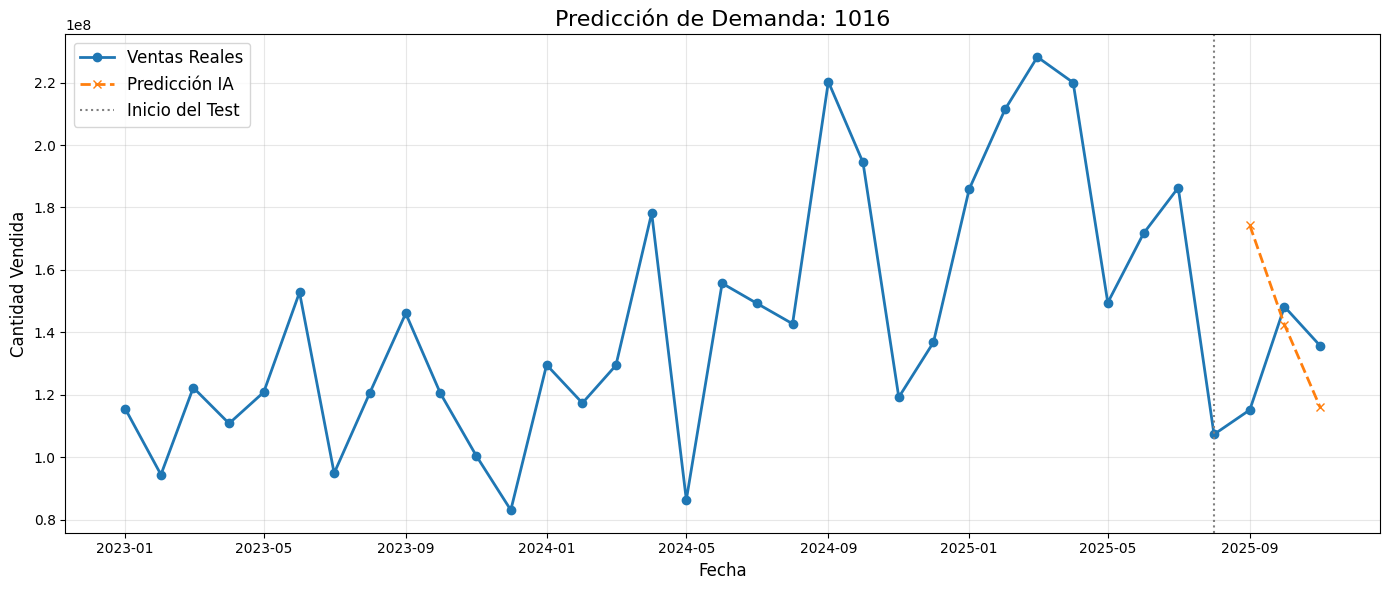

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Organizar los datos para graficar
df_final = df_st.copy()
df_results = test.copy()
df_results['Prediccion'] = y_pred   # usar las predicciones del modelo ganador

# 2. Elegir un Producto TOP para el ejemplo (el más vendido)
top_product_id = df_st.groupby('ID_Producto')['Cantidad'].sum().idxmax()
nombre_producto = df_final[df_final['ID_Producto'] == top_product_id]['Producto'].iloc[0]

# Filtrar datos solo de ese producto
historia_producto = df_st[df_st['ID_Producto'] == top_product_id]
prediccion_producto = df_results[df_results['ID_Producto'] == top_product_id]

# 3. Crear el gráfico
plt.figure(figsize=(14, 6))

# Graficar la historia real (Entrenamiento + Test)
plt.plot(historia_producto['Fecha_Mensual'], historia_producto['Cantidad'],
         label='Ventas Reales', color='tab:blue', linewidth=2, marker='o')

# Graficar la predicción (solo en la parte de Test)
plt.plot(prediccion_producto['Fecha_Mensual'], prediccion_producto['Prediccion'],
         label='Predicción IA', color='tab:orange', linewidth=2, linestyle='--', marker='x')

# Formato
plt.title(f"Predicción de Demanda: {nombre_producto}", fontsize=16)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Cantidad Vendida", fontsize=12)
plt.axvline(x=fecha_corte, color='gray', linestyle=':', label='Inicio del Test')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

C:\Users\joseb\AppData\Local\Temp\ipykernel_16848\3020915844.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis')


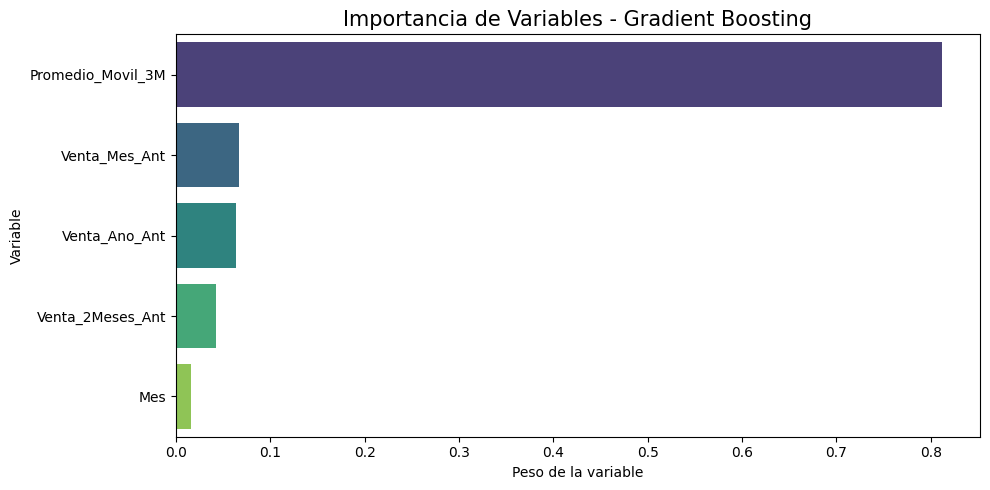

In [40]:
# Extraer el modelo ganador del pipeline
modelo_final = winner_model.named_steps['regressor']

# Crear DataFrame de Importancia o Coeficientes según el tipo de modelo
if hasattr(modelo_final, "feature_importances_"):
    importancia = pd.DataFrame({
        'Variable': features,
        'Importancia': modelo_final.feature_importances_
    }).sort_values('Importancia', ascending=False)
elif hasattr(modelo_final, "coef_"):
    importancia = pd.DataFrame({
        'Variable': features,
        'Importancia': modelo_final.coef_
    }).sort_values('Importancia', ascending=False)
else:
    raise ValueError("El modelo ganador no soporta importancia de variables")

# Graficar
plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis')
plt.title(f"Importancia de Variables - {winner_name}", fontsize=15)
plt.xlabel("Peso de la variable")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

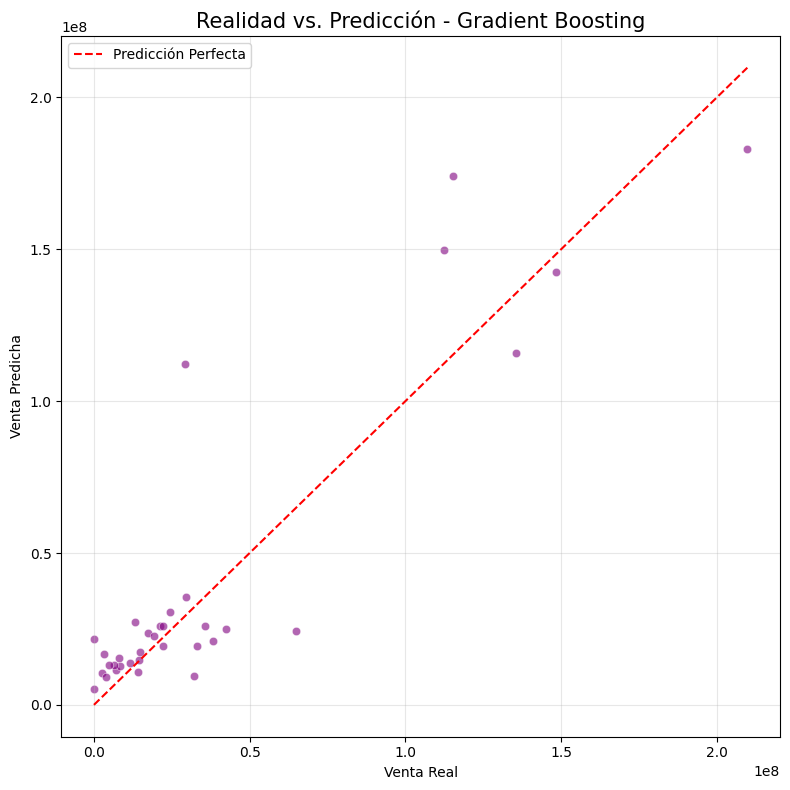

In [41]:
# Gráfico de Realidad vs Predicción con el modelo ganador
plt.figure(figsize=(8, 8))

# Usamos el conjunto de test y las predicciones del modelo ganador
sns.scatterplot(x=test[target], y=y_pred, alpha=0.6, color='purple')

# Línea de perfección (45 grados)
max_val = max(test[target].max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción Perfecta')

# Formato
plt.title(f"Realidad vs. Predicción - {winner_name}", fontsize=15)
plt.xlabel("Venta Real")
plt.ylabel("Venta Predicha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
'''
Basado en la prediccion del modelo y asumiendo un stock de seguridad del 10%,
estas son las sugerencias de compra para el proximo mes
'''


'\nBasado en la prediccion del modelo y asumiendo un stock de seguridad del 10%,\nestas son las sugerencias de compra para el proximo mes\n'

In [43]:
'''
NO SUPERVISADO: La Segmentacion de Clientes
Este modelo es fundamental para responder la pregunta:
Quienes son mis mejores clientes y a quienes estoy perdiendo?
Usaremos la tecnica RFM (Recency, Frequency, Monetary) combinada con un algoritmo con un
algoritmo de K-Means Clusterings.
'''

'\nNO SUPERVISADO: La Segmentacion de Clientes\nEste modelo es fundamental para responder la pregunta:\nQuienes son mis mejores clientes y a quienes estoy perdiendo?\nUsaremos la tecnica RFM (Recency, Frequency, Monetary) combinada con un algoritmo con un\nalgoritmo de K-Means Clusterings.\n'

--- Construyendo perfil de clientes (RFM) ---
Total de Clientes únicos a segmentar: 1826
💾 Transformador RFM guardado en C:\Users\joseb\Desktop\proyecto_cm_ml\models\rfm_scaler.pkl

--- Selección de K con Silhouette ---
K=2 -> Silhouette: 0.5388
K=3 -> Silhouette: 0.5825
K=4 -> Silhouette: 0.6117
K=5 -> Silhouette: 0.6245
K=6 -> Silhouette: 0.5317
K=7 -> Silhouette: 0.5316
K=8 -> Silhouette: 0.5464
K=9 -> Silhouette: 0.5258
K=10 -> Silhouette: 0.5262

🌟 Mejor número de clusters: K=5
💾 Modelo KMeans guardado en C:\Users\joseb\Desktop\proyecto_cm_ml\models\rfm_kmeans_model.pkl


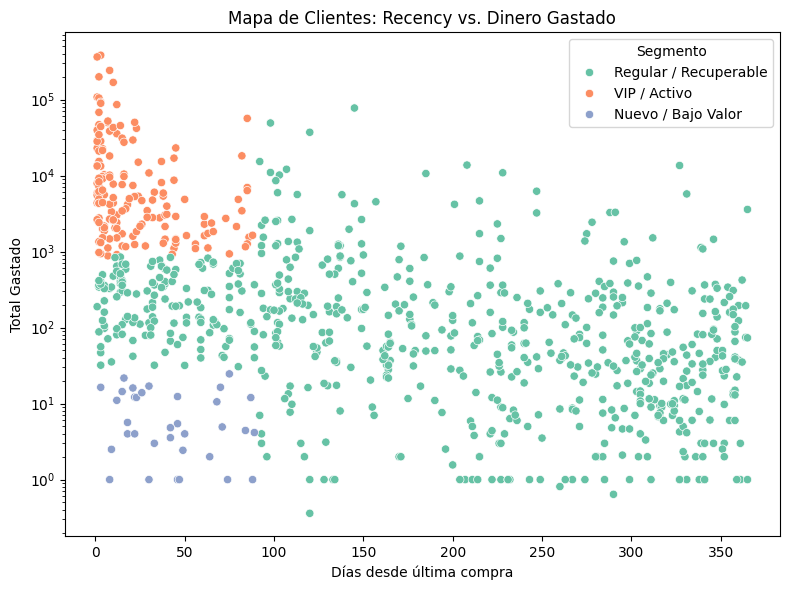

In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# -------------------------------
# 1. Construcción del perfil RFM
# -------------------------------
print("--- Construyendo perfil de clientes (RFM) ---")
fecha_actual = df_completo["Fecha"].max() + pd.Timedelta(days=1)

df_clientes = df_completo.groupby('Cliente').agg({
    "Fecha": lambda x: (fecha_actual - x.max()).days,  # Recency
    "Total": ["count", "sum"]                         # Frequency, Monetary
}).reset_index()

df_clientes.columns = ['Cliente', 'Recency', 'Frequency', 'Monetary']
df_clientes = df_clientes[df_clientes["Monetary"] > 0]

print(f"Total de Clientes únicos a segmentar: {len(df_clientes)}")

# -------------------------------
# 2. Filtrar clientes inactivos
# -------------------------------
limite_recency = 365
df_clientes['Estado'] = np.where(df_clientes['Recency'] > limite_recency, 'Inactivo', 'Activo')
df_segmentables = df_clientes[df_clientes['Estado'] == 'Activo'].copy()

# -------------------------------
# 3. Escalado RFM
# -------------------------------
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_segmentables[['Recency','Frequency','Monetary']])

# Guardar transformador RFM
save_path = r"C:\Users\joseb\Desktop\proyecto_cm_ml\models"
os.makedirs(save_path, exist_ok=True)
joblib.dump(scaler, os.path.join(save_path, "rfm_scaler.pkl"))
print(f"💾 Transformador RFM guardado en {save_path}\\rfm_scaler.pkl")

# -------------------------------
# 4. Selección de K óptimo
# -------------------------------
print("\n--- Selección de K con Silhouette ---")
sil_scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    sil_scores[k] = silhouette_score(rfm_scaled, labels)
    print(f"K={k} -> Silhouette: {sil_scores[k]:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n🌟 Mejor número de clusters: K={best_k}")

# -------------------------------
# 5. Entrenar modelo final
# -------------------------------
final_model = KMeans(n_clusters=best_k, random_state=42)
df_segmentables['Cluster'] = final_model.fit_predict(rfm_scaled)

# Guardar modelo KMeans
joblib.dump(final_model, os.path.join(save_path, "rfm_kmeans_model.pkl"))
print(f"💾 Modelo KMeans guardado en {save_path}\\rfm_kmeans_model.pkl")

# -------------------------------
# 6. Etiquetado inteligente
# -------------------------------
q1 = df_segmentables['Monetary'].quantile(0.25)
q3 = df_segmentables['Monetary'].quantile(0.75)

def etiquetar_cliente(row):
    if row['Recency'] < 90 and row['Monetary'] > q3:
        return 'VIP / Activo'
    elif row['Recency'] > 365 and row['Monetary'] < q1:
        return 'Dormido / Bajo Valor'
    elif row['Recency'] < 90 and row['Monetary'] < q1:
        return 'Nuevo / Bajo Valor'
    else:
        return 'Regular / Recuperable'

df_segmentables['Segmento'] = df_segmentables.apply(etiquetar_cliente, axis=1)

# -------------------------------
# 7. Visualización
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_segmentables, x='Recency', y='Monetary', hue='Segmento', palette='Set2')
plt.title("Mapa de Clientes: Recency vs. Dinero Gastado")
plt.xlabel("Días desde última compra")
plt.ylabel("Total Gastado")
plt.yscale('log')
plt.tight_layout()
plt.show()

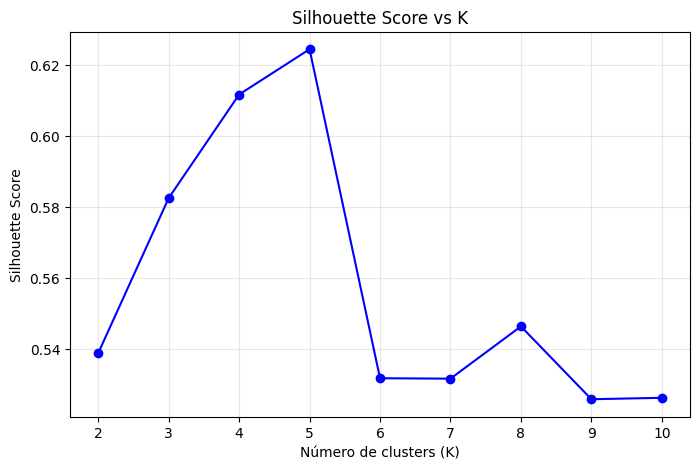

In [46]:
import matplotlib.pyplot as plt

# Graficar Silhouette vs K
plt.figure(figsize=(8,5))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='blue')
plt.title("Silhouette Score vs K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()
